In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset 2.csv to Dataset 2.csv


In [ ]:
# Q1.Load the dataset and display the first five records.
import pandas as pd
df = pd.read_csv('Dataset 2.csv')
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [ ]:
# Q2.Determine the number of rows and columns in the dataset.
print("Rows and Columns:", df.shape)

Rows and Columns: (750, 10)


In [ ]:
# Q3.Display all column names.
print(df.columns)

Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


In [ ]:
# Q4.Identify numerical and categorical features.
print("Numerical Features:")
print(df.select_dtypes(include=['int64','float64']).columns)

print("\nCategorical Features:")
print(df.select_dtypes(include=['object']).columns)

Numerical Features:
Index(['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks',
       'MonthlySpend'],
      dtype='object')

Categorical Features:
Index(['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed'], dtype='object')


In [ ]:
# Q5.Check whether the dataset contains missing values.
print(df.isnull().sum())

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


In [ ]:
# Q6.Calculate the average age of users.
print("Average Age =", df['Age'].mean())

Average Age = 41.824


In [ ]:
# Q7.Determine the average watch hours per week.
print("Average Watch Hours =", df['WatchHoursPerWeek'].mean())

Average Watch Hours = 14.236


In [ ]:
# Q8.Find the average monthly spending of users.
print("Average Monthly Spend =", df['MonthlySpend'].mean())

Average Monthly Spend = 689.9053333333334


In [ ]:
# Q9.Count the number of users in each subscription category.
print(df['SubscriptionType'].value_counts())

SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


In [ ]:
# Q10.Determine the percentage of users who renewed their subscriptions.
renewal_percentage = (df['SubscriptionRenewed'] == 'Yes').mean()*100
print("Renewal Percentage =", renewal_percentage,"%")

Renewal Percentage = 46.266666666666666 %


In [ ]:
# Q11.Convert categorical features into numerical form.
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
encoder = LabelEncoder()
for col in ['Gender','SubscriptionType','FavoriteGenre','SubscriptionRenewed']:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
df_encoded.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


In [ ]:
# Q12.Define the feature set (X) and target variable (y) for subscription renewal prediction.
X = df_encoded.drop('SubscriptionRenewed', axis=1)
y = df_encoded['SubscriptionRenewed']

print("Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Features (X):
   UserID  Age  Gender  SubscriptionType  WatchHoursPerWeek  DevicesUsed  \
0    1001   22       0                 0                 23            5   
1    1002   55       1                 0                  9            4   
2    1003   49       1                 0                  8            3   
3    1004   39       0                 1                 19            5   
4    1005   38       0                 1                 23            5   

   FavoriteGenre  AdClicks  MonthlySpend  
0              1        13           353  
1              2        14           317  
2              1        16           309  
3              2        45           833  
4              5        24           804  

Target Variable (y):
0    0
1    1
2    0
3    1
4    1
Name: SubscriptionRenewed, dtype: int64


In [ ]:
# Q13.Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (600, 9)
Testing Data Shape: (150, 9)


In [ ]:
# Q14.Train a Decision Tree model to predict whether a user will renew their subscription.
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [ ]:
# Q15.Evaluate the model using accuracy.
from sklearn.metrics import accuracy_score
y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy =", dt_accuracy)

Decision Tree Accuracy = 0.5666666666666667


Confusion Matrix:
[[50 32]
 [33 35]]


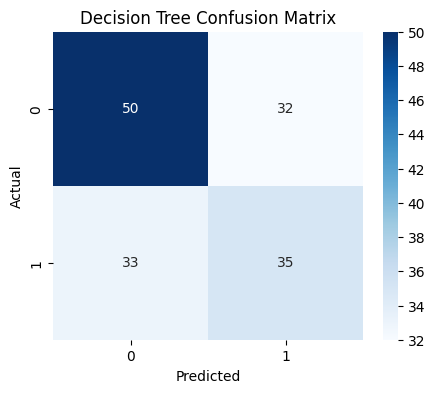

In [ ]:
# Q16.Generate and interpret the confusion matrix.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(cm)
# Visualize Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Q17.Train a KNN classifier with K = 5.
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("KNN Model Trained")

KNN Model Trained


In [ ]:
# Q18.Compare the accuracy of KNN with the Decision Tree model.
y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("Decision Tree Accuracy =", dt_accuracy)
print("KNN Accuracy =", knn_accuracy)

Decision Tree Accuracy = 0.5666666666666667
KNN Accuracy = 0.6


In [ ]:
# Q19.Train a Linear Regression model to predict monthly spending.
from sklearn.linear_model import LinearRegression
X_reg = df_encoded.drop('MonthlySpend', axis=1)
y_reg = df_encoded['MonthlySpend']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)
lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
print("Linear Regression Model Trained")

Linear Regression Model Trained


In [ ]:
# Q20.Predict the monthly spending for a new user and interpret the result.
new_user = [[1001,22,0,1,15,3,2,10,1]]
prediction = lr.predict(new_user)
print("Predicted Monthly Spending = ₹", prediction[0])

Predicted Monthly Spending = ₹ 833.5666425239353


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
''' Business Reflection Questions

1. Which factors appear to influence subscription renewal the most?
The factors that may influence subscription renewal include subscription type, watch hours per week, monthly spending, number of devices used, favorite genre, and user
engagement. Users who watch more content and spend more money are generally more likely to renew their subscriptions.

2. Why is subscription renewal a classification problem?
Subscription renewal is a classification problem because the target variable has two categories: "Yes" and "No". The model predicts which class a user belongs to.

3. Why is monthly spending a regression problem?
Monthly spending is a regression problem because the target variable is a continuous numerical value. The model predicts an exact amount rather than a category.

4. Which algorithm performed better for renewal prediction?
The algorithm with the higher accuracy score on the test dataset performed better. The comparison should be made between the Decision Tree and KNN accuracy values
obtained during model evaluation.

5. How could the platform use these predictions to improve customer retention?
Netflix can identify users who are likely to cancel their subscriptions and provide personalized recommendations, discounts, loyalty rewards, or targeted marketing campaigns
 to encourage renewal and improve customer retention.
 '''

' Business Reflection Questions  \n\n1. Which factors appear to influence subscription renewal the most? \nThe factors that may influence subscription renewal include subscription type, watch hours per week, monthly spending, number of devices used, favorite genre, and user \nengagement. Users who watch more content and spend more money are generally more likely to renew their subscriptions.\n\n2. Why is subscription renewal a classification problem? \nSubscription renewal is a classification problem because the target variable has two categories: "Yes" and "No". The model predicts which class a user belongs to.\n\n3. Why is monthly spending a regression problem?  \nMonthly spending is a regression problem because the target variable is a continuous numerical value. The model predicts an exact amount rather than a category.\n\n4. Which algorithm performed better for renewal prediction?  \nThe algorithm with the higher accuracy score on the test dataset performed better. The comparison 